# 02 — User-Based Collaborative Filtering

**Hour 2, 70–95 min: The user-item matrix, similarity, and recommendations**

This is where the recommendation engine actually starts to take shape. We'll:
1. Build the user-item matrix
2. Handle missing values for similarity calculation
3. Calculate user-user similarity with cosine similarity
4. Find users most similar to a target user
5. Generate recommendations for that user, using a reusable function

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (9, 5.5)

ratings = pd.read_csv("../data/movie_ratings_dataset.csv")
ratings.head()

,user_id,movie_id,movie_title,genre,rating
0,U158,M045,The Wedding Planner's Heart,Romance,5
1,U399,M036,Synthetic Dawn,Sci-Fi,4
2,U348,M038,Parallel Code,Sci-Fi,3
3,U314,M047,"Two Hearts, One City",Romance,4
4,U245,M054,Nightfall Manor,Horror,5


## Step 1 — Create the User-Item Matrix

**What are we doing?** Reshaping the ratings table so that rows are users, columns are
movies, and each cell holds that user's rating for that movie.

In [2]:
user_item_matrix = ratings.pivot_table(
    index="user_id",
    columns="movie_title",
    values="rating"
)

print(f"Matrix shape: {user_item_matrix.shape[0]} users x {user_item_matrix.shape[1]} movies")
user_item_matrix.iloc[:5, :6]

Matrix shape: 300 users x 60 movies


movie_title,A Winter's Promise,Apex Strike,Autumn in Paris,Beyond the Rift,Blackout Squad,Blind Date Bingo
user_id,,,,,,
U100,2.0,NaN,NaN,NaN,4.0,NaN
U101,NaN,NaN,3.0,NaN,NaN,NaN
U102,NaN,NaN,NaN,4.0,3.0,NaN
U103,5.0,4.0,NaN,NaN,4.0,NaN
U104,NaN,2.0,NaN,NaN,NaN,4.0


**What does this table mean?**
- Each ROW is one user's complete rating profile.
- Each COLUMN is one movie.
- A number is a rating that user actually gave.
- `NaN` means that user never rated that movie — we simply don't know their opinion.

This is exactly the user-item matrix from the slides, built with real data.

## Step 2 — Handle Missing Values

**Why do we need to do this?** `cosine_similarity()` compares rows of numbers — it can't work
with `NaN`. But we also can't just DROP missing values, since almost every user has some.

**The common beginner-friendly approach:** fill missing ratings with `0`.

**Why does this work reasonably well here?** Our rating scale is 1–5, so a `0` doesn't
correspond to a real (very bad) rating — it effectively means "no opinion," and it contributes
very little to the similarity calculation between two users who both didn't rate that movie
(0 x 0 = 0). It's an approximation, not a perfect solution — production systems often use more
careful techniques (like mean-centering), but filling with 0 is a good, honest starting point
for understanding the workflow.

In [3]:
user_item_filled = user_item_matrix.fillna(0)
user_item_filled.iloc[:5, :6]

movie_title,A Winter's Promise,Apex Strike,Autumn in Paris,Beyond the Rift,Blackout Squad,Blind Date Bingo
user_id,,,,,,
U100,2.0,0.0,0.0,0.0,4.0,0.0
U101,0.0,0.0,3.0,0.0,0.0,0.0
U102,0.0,0.0,0.0,4.0,3.0,0.0
U103,5.0,4.0,0.0,0.0,4.0,0.0
U104,0.0,2.0,0.0,0.0,0.0,4.0


## Step 3 — Calculate User Similarity

**What are we doing?** Comparing every user's rating profile (row) against every other user's,
using cosine similarity.

**What does this compare?** Interaction PATTERNS — which movies a user rated, and how highly —
not the movie descriptions themselves.

In [4]:
user_similarity = cosine_similarity(user_item_filled)

# Turn the result back into a labelled DataFrame for readability
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_filled.index,
    columns=user_item_filled.index,
)

user_similarity_df.iloc[:5, :5].round(2)

user_id,U100,U101,U102,U103,U104
user_id,,,,,
U100,1.00,0.00,0.36,0.51,0.02
U101,0.00,1.00,0.18,0.13,0.13
U102,0.36,0.18,1.00,0.25,0.00
U103,0.51,0.13,0.25,1.00,0.42
U104,0.02,0.13,0.00,0.42,1.00


**Reading this table:** the value in row U100, column U100 is 1.0 — every user is perfectly similar to themselves. That diagonal of 1.0s is expected and we'll need to exclude it when looking for OTHER similar users.

## Step 4 — Find Similar Users

**Which users are most similar to a chosen target user?**

In [5]:
target_user = "U100"

similar_users = (
    user_similarity_df[target_user]
    .drop(target_user)          # exclude the user themselves
    .sort_values(ascending=False)
    .head(8)
)

similar_users

user_id
U340    0.822329
U246    0.755255
U117    0.748331
U157    0.745810
U277    0.723877
U270    0.716541
U182    0.709925
U297    0.700270
Name: U100, dtype: float64

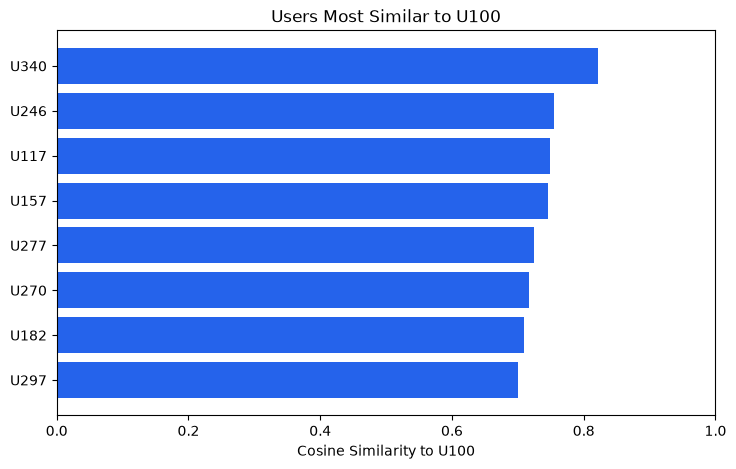

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(similar_users.index[::-1], similar_users.values[::-1], color="#2563EB")
ax.set_xlabel(f"Cosine Similarity to {target_user}")
ax.set_title(f"Users Most Similar to {target_user}")
ax.set_xlim(0, 1)
plt.show()

**Sanity check — do these similar users actually share taste?** Let's peek at what
`target_user` and their single most similar user both rated highly.

In [7]:
most_similar_user = similar_users.index[0]

print(f"{target_user}'s ratings:")
print(ratings[ratings.user_id == target_user][["movie_title", "genre", "rating"]]
      .sort_values("rating", ascending=False).to_string(index=False))

print(f"\n{most_similar_user}'s ratings:")
print(ratings[ratings.user_id == most_similar_user][["movie_title", "genre", "rating"]]
      .sort_values("rating", ascending=False).to_string(index=False))

U100's ratings:
                movie_title   genre  rating
             Steel Vendetta  Action       5
           Midnight Pursuit  Action       5
              Rogue Circuit  Action       5
           Last Stand Alpha  Action       5
              Ghost Payload  Action       5
             Blackout Squad  Action       4
            Titan Fall Zero  Action       4
          Midnight Serenade Romance       3
         A Winter's Promise   Drama       2
The Wedding Planner's Heart Romance       2
               Office Chaos  Comedy       1

U340's ratings:
          movie_title  genre  rating
     Midnight Pursuit Action       5
       Blackout Squad Action       5
The Weight of Silence  Drama       4
     Last Stand Alpha Action       4
        Ghost Payload Action       4
      Titan Fall Zero Action       4
       Steel Vendetta Action       4
        Rogue Circuit Action       4
      Beyond the Rift Sci-Fi       3
   Dog Sitter Diaries Comedy       3
      The Cellar Door Horror    

You should see both users' highly-rated movies clustering around the SAME genre — that's exactly why cosine similarity picked this user out as similar. The algorithm never saw the word "genre" — it discovered this purely from rating patterns.

## Step 5 — Generate User-Based Recommendations

The workflow, exactly as in the slides:

```
Target User → Find Similar Users → Look at Items They Like →
Remove Items Target User Already Knows → Rank Remaining Items → Recommend Top Items
```

Let's build this as a reusable function.

In [8]:
def recommend_movies_user_based(user_id, top_n=5, n_similar_users=10):
    """
    Recommends movies for `user_id` using user-based collaborative filtering.
    """
    # 1. Find the most similar users to the target user
    similar = (
        user_similarity_df[user_id]
        .drop(user_id)
        .sort_values(ascending=False)
        .head(n_similar_users)
    )

    # 2. Movies the target user has already rated (to exclude from recommendations)
    already_rated = user_item_matrix.loc[user_id].dropna().index

    # 3. Collect ratings from similar users, weighted by how similar they are
    weighted_scores = pd.Series(dtype=float)
    similarity_totals = pd.Series(dtype=float)

    for other_user, similarity_score in similar.items():
        other_ratings = user_item_matrix.loc[other_user].dropna()
        for movie, rating in other_ratings.items():
            if movie in already_rated:
                continue  # don't recommend something the user already knows
            weighted_scores[movie] = weighted_scores.get(movie, 0) + rating * similarity_score
            similarity_totals[movie] = similarity_totals.get(movie, 0) + similarity_score

    if len(weighted_scores) == 0:
        return pd.Series(dtype=float)  # no recommendations possible

    # 4. Rank by the similarity-weighted average predicted rating
    predicted_scores = (weighted_scores / similarity_totals).sort_values(ascending=False)

    # 5. Return the top N
    return predicted_scores.head(top_n)


recommendations = recommend_movies_user_based("U100", top_n=5)
recommendations

Rainy Day Promises       5.000000
Iron Protocol            4.597322
Apex Strike              4.373893
Crimson Velocity         4.339293
The Weight of Silence    4.000000
dtype: float64

**What does the output mean?** Each value is a PREDICTED rating (roughly on the same
1-5 scale) for a movie `U100` has not yet seen, based on what similar users thought of it —
weighted so that more-similar users have more influence on the prediction.

**Let's check the genres of these recommendations against the target user's favourite genre:**

In [9]:
genre_lookup = ratings.drop_duplicates("movie_title").set_index("movie_title")["genre"]

rec_table = pd.DataFrame({
    "predicted_rating": recommendations.round(2),
    "genre": genre_lookup.reindex(recommendations.index),
})
rec_table

,predicted_rating,genre
Rainy Day Promises,5.00,Romance
Iron Protocol,4.60,Action
Apex Strike,4.37,Action
Crimson Velocity,4.34,Action
The Weight of Silence,4.00,Drama


### Recap
- We built the user-item matrix with `pivot_table()`.
- We filled missing values with 0 so `cosine_similarity()` could run, and discussed why that's
  a reasonable (if imperfect) beginner approach.
- We calculated user-user similarity and confirmed it picks out genuinely similar tastes.
- We built a complete `recommend_movies_user_based()` function that follows the exact workflow
  from the slides.

**Next: `03_Item_Based_Collaborative_Filtering.ipynb`** — the same idea, flipped to compare
movies instead of users.